## Sketch Value Experiment

In [1]:
m = int(2e6)

In [2]:
import pandas as pd

rm_space = lambda x: x.strip()
cs_vals = pd.read_csv("Data/ss-ssa-count-sketch-vals.txt").rename(rm_space, axis="columns")
gem_vals = pd.read_csv("Data/ss-ssa-gemini-vals-26.txt").rename(rm_space, axis="columns")
lstm_vals = pd.read_csv("Data/ss-ssa-lstm-vals.txt").rename(rm_space, axis="columns")

In [3]:
cs_vals

,Ground Truth,SSA Estimate,SS Estimate,SSA Error,SS Error,Timestep
0,43573.346,41710.421,23763.265,1.045,1.834,1.0
1,32479.631,29279.965,19339.064,1.109,1.679,636230.0
2,19883.685,18361.807,13160.281,1.083,1.511,1212782.0
3,15090.933,14055.033,6499.341,1.074,2.322,1391338.0
4,9914.098,9085.389,4507.855,1.091,2.199,1581107.0
5,6841.244,6005.547,3147.501,1.139,2.174,1710892.0
6,4420.419,3587.274,1831.024,1.232,2.414,1814452.0
7,3270.308,2306.338,1056.146,1.418,3.096,1878133.0
8,2480.011,1675.675,826.653,1.480,3.000,1905773.0
9,1540.096,1081.530,583.757,1.424,2.638,1935134.0


In [4]:
gem_vals

,Ground Truth,SSA Estimate,SS Estimate,SSA Error,SS Error,Timestep
0,43573.346,42013.892,23763.265,1.037,1.834,1.0
1,23116.553,21207.331,15804.199,1.090,1.463,1069420.0
2,15392.072,14171.277,6727.261,1.086,2.288,1374556.0
3,8518.798,7533.261,3761.891,1.131,2.264,1646426.0
4,5385.345,4552.943,2492.374,1.183,2.161,1766070.0
5,3843.061,2920.323,1422.253,1.316,2.702,1845425.0
6,2723.148,1857.561,918.326,1.466,2.965,1898815.0
7,1321.874,962.194,493.672,1.374,2.678,1942346.0
8,1016.198,639.467,396.074,1.589,2.566,1952179.0
9,696.164,426.714,286.243,1.631,2.432,1960229.0


In [5]:
lstm_vals

,Ground Truth,SSA Estimate,SS Estimate,SSA Error,SS Error,Timestep
0,43573.346,42073.973,23763.265,1.036,1.834,1.0
1,32751.344,30180.567,19433.398,1.085,1.685,620553.0
2,19586.723,18372.694,12972.398,1.066,1.510,1226274.0
3,13941.371,12709.385,6141.546,1.097,2.270,1423295.0
4,8768.536,7809.687,3901.180,1.123,2.248,1634250.0
5,6722.284,5764.647,3038.154,1.166,2.213,1715933.0
6,4797.147,3903.307,2067.939,1.229,2.320,1793269.0
7,3257.384,2227.707,1053.132,1.462,3.093,1878623.0
8,2308.082,1548.869,811.588,1.490,2.844,1911300.0
9,1231.355,848.997,456.601,1.450,2.697,1947122.0


In [6]:
cs_windows = m - cs_vals["Timestep"]
gem_windows = m - gem_vals["Timestep"]
lstm_windows = m - lstm_vals["Timestep"]

align = lambda w: cs_vals.loc[(w - cs_windows).abs().argmin(), "Timestep"]

gem_vals["Timestep"] = list(map(align, gem_windows))
lstm_vals["Timestep"] = list(map(align, lstm_windows))

In [7]:
gem_vals

,Ground Truth,SSA Estimate,SS Estimate,SSA Error,SS Error,Timestep
0,43573.346,42013.892,23763.265,1.037,1.834,1.0
1,23116.553,21207.331,15804.199,1.090,1.463,1212782.0
2,15392.072,14171.277,6727.261,1.086,2.288,1391338.0
3,8518.798,7533.261,3761.891,1.131,2.264,1710892.0
4,5385.345,4552.943,2492.374,1.183,2.161,1814452.0
5,3843.061,2920.323,1422.253,1.316,2.702,1814452.0
6,2723.148,1857.561,918.326,1.466,2.965,1905773.0
7,1321.874,962.194,493.672,1.374,2.678,1935134.0
8,1016.198,639.467,396.074,1.589,2.566,1952807.0
9,696.164,426.714,286.243,1.631,2.432,1961489.0


In [8]:
lstm_vals

,Ground Truth,SSA Estimate,SS Estimate,SSA Error,SS Error,Timestep
0,43573.346,42073.973,23763.265,1.036,1.834,1.0
1,32751.344,30180.567,19433.398,1.085,1.685,636230.0
2,19586.723,18372.694,12972.398,1.066,1.510,1212782.0
3,13941.371,12709.385,6141.546,1.097,2.270,1391338.0
4,8768.536,7809.687,3901.180,1.123,2.248,1581107.0
5,6722.284,5764.647,3038.154,1.166,2.213,1710892.0
6,4797.147,3903.307,2067.939,1.229,2.320,1814452.0
7,3257.384,2227.707,1053.132,1.462,3.093,1878133.0
8,2308.082,1548.869,811.588,1.490,2.844,1905773.0
9,1231.355,848.997,456.601,1.450,2.697,1952807.0


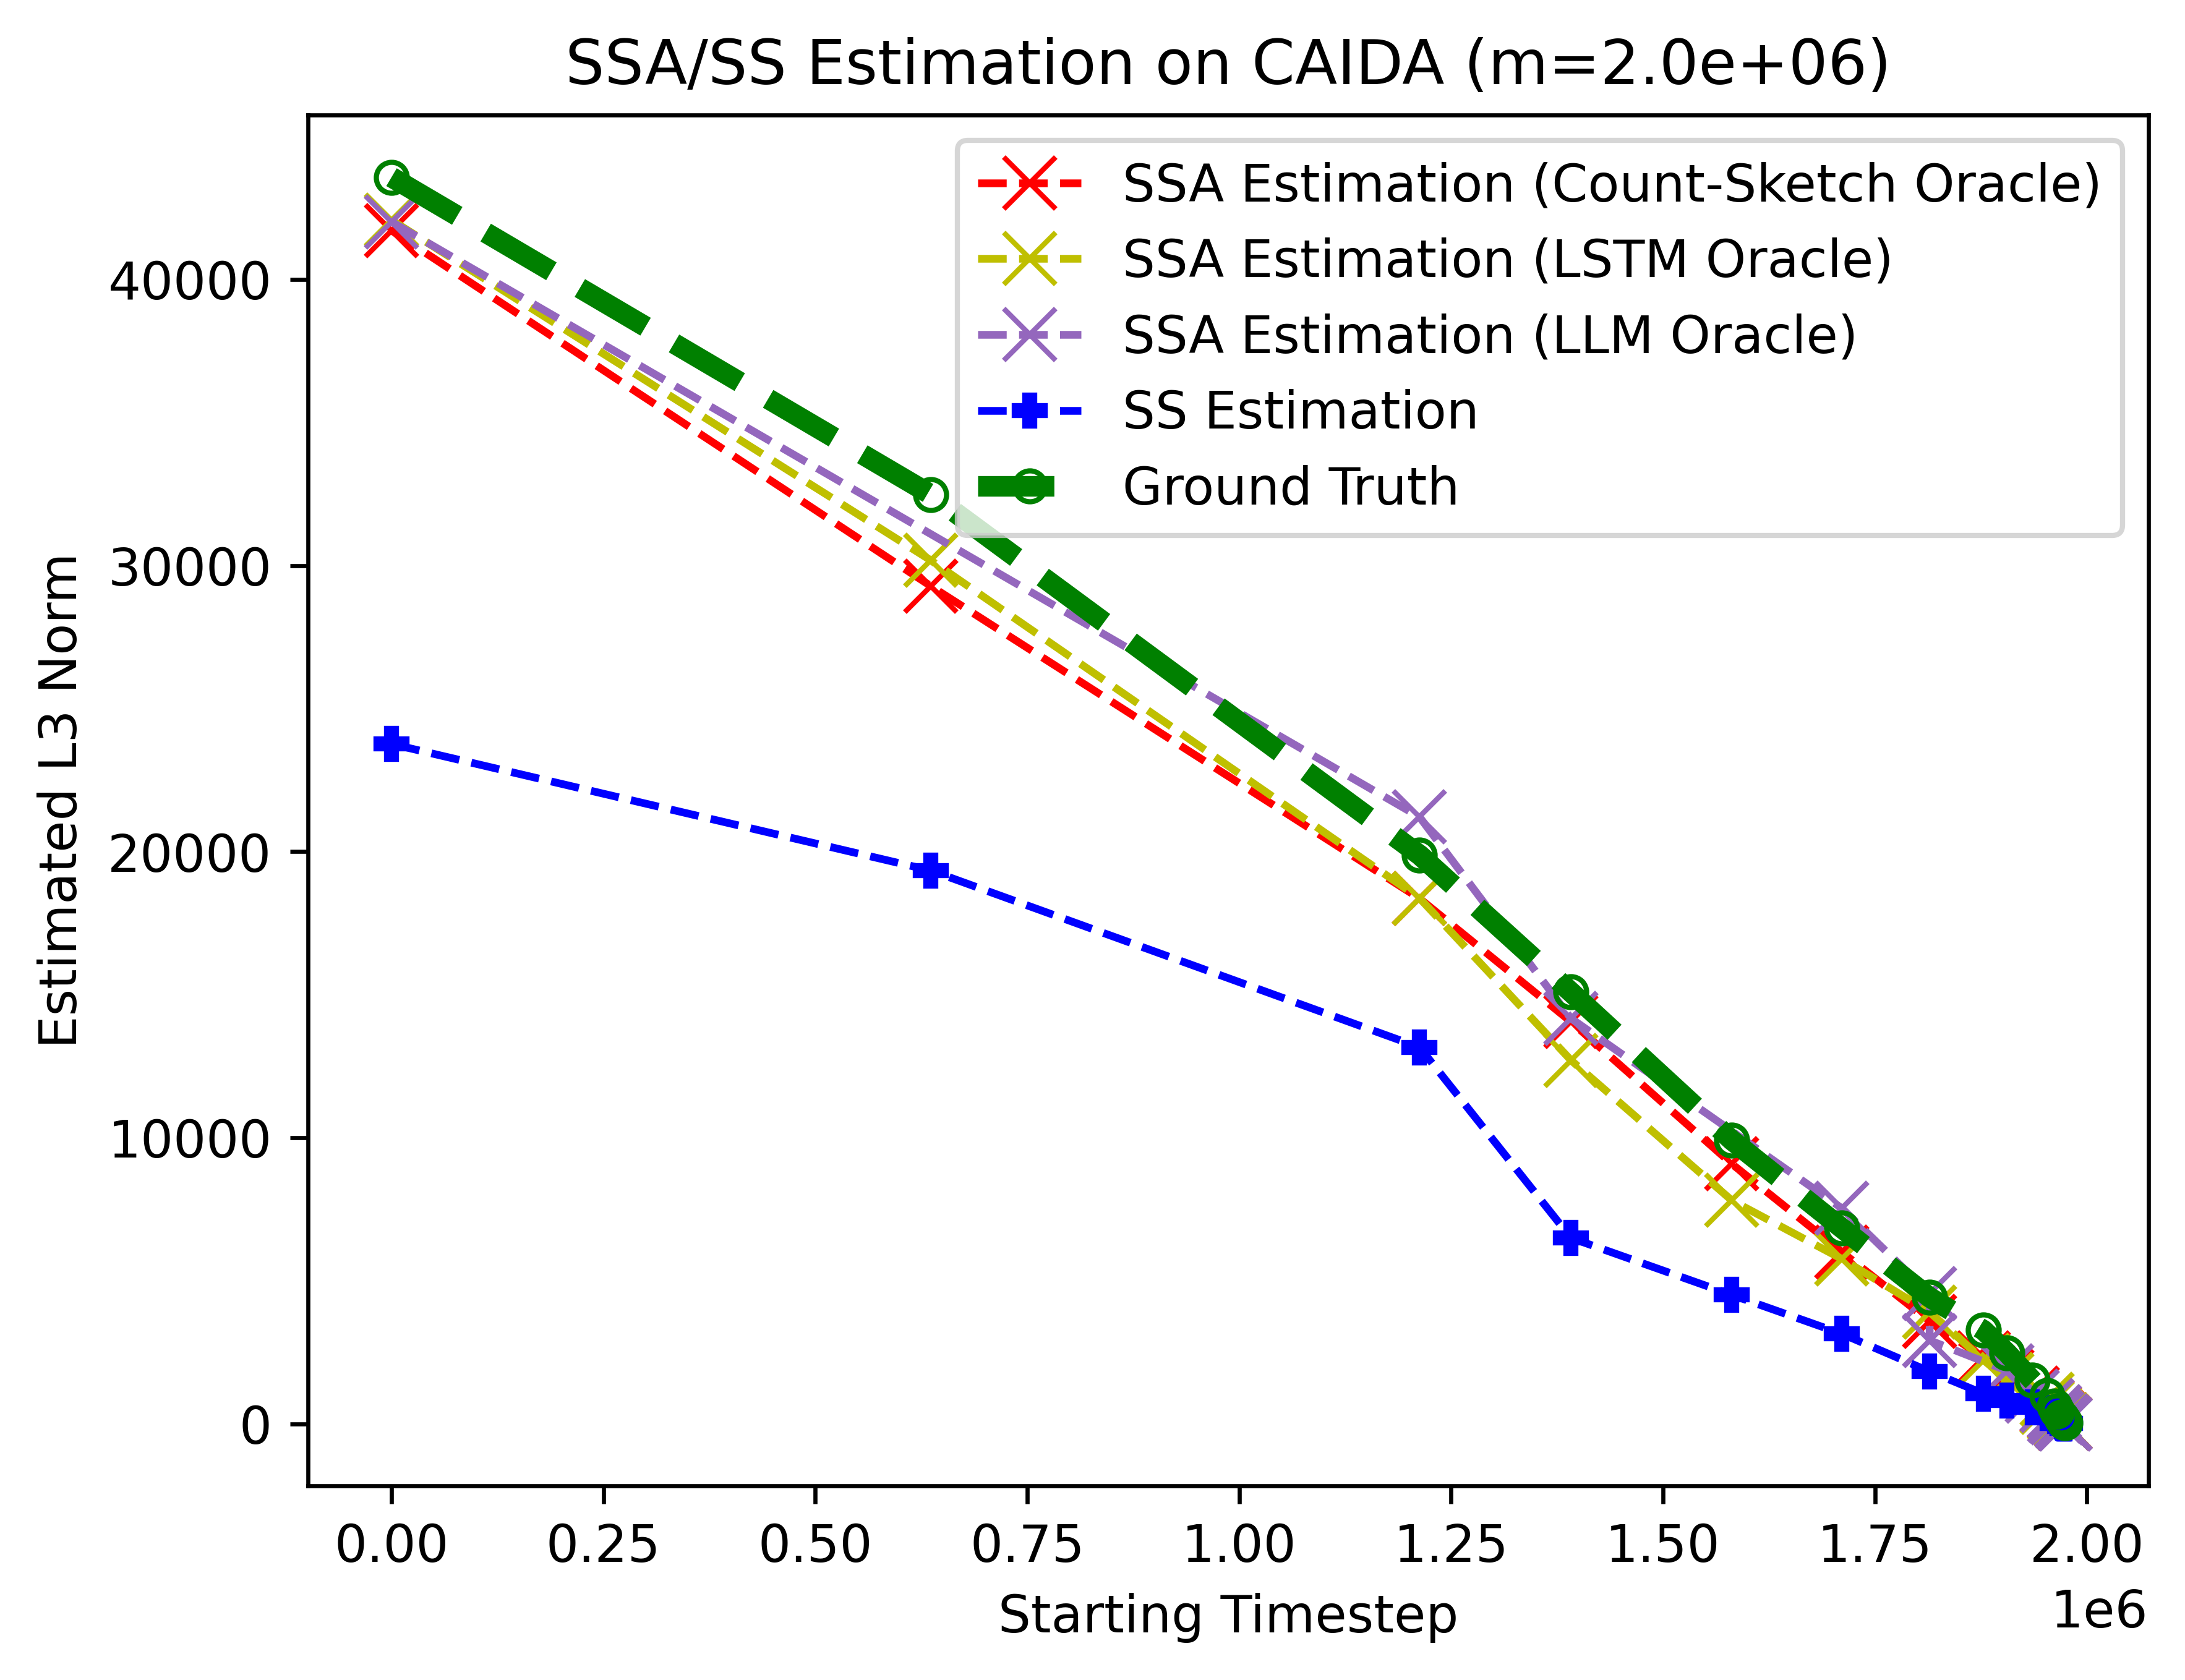

In [9]:

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["figure.dpi"] = 600

## plot estimates
_, ax = plt.subplots()

ax.plot(cs_vals["Timestep"], cs_vals["SSA Estimate"], 'rx--', label="SSA Estimation (Count-Sketch Oracle)", markersize=10)
ax.plot(lstm_vals["Timestep"], lstm_vals["SSA Estimate"], 'yx--', label="SSA Estimation (LSTM Oracle)", markersize=10)
ax.plot(gem_vals["Timestep"], gem_vals["SSA Estimate"], 'x--', label="SSA Estimation (LLM Oracle)", color="tab:purple",
        markersize=10)
ax.plot(cs_vals["Timestep"], cs_vals['SS Estimate'], 'bP--', label="SS Estimation")
ax.plot(cs_vals["Timestep"], cs_vals["Ground Truth"], 'go--', label="Ground Truth", fillstyle='none', linewidth=4)
ax.set_title(f"SSA/SS Estimation on CAIDA (m={m:.1e})")
ax.set_xlabel("Starting Timestep")
ax.set_ylabel("Estimated L3 Norm")
ax.legend()
plt.show()

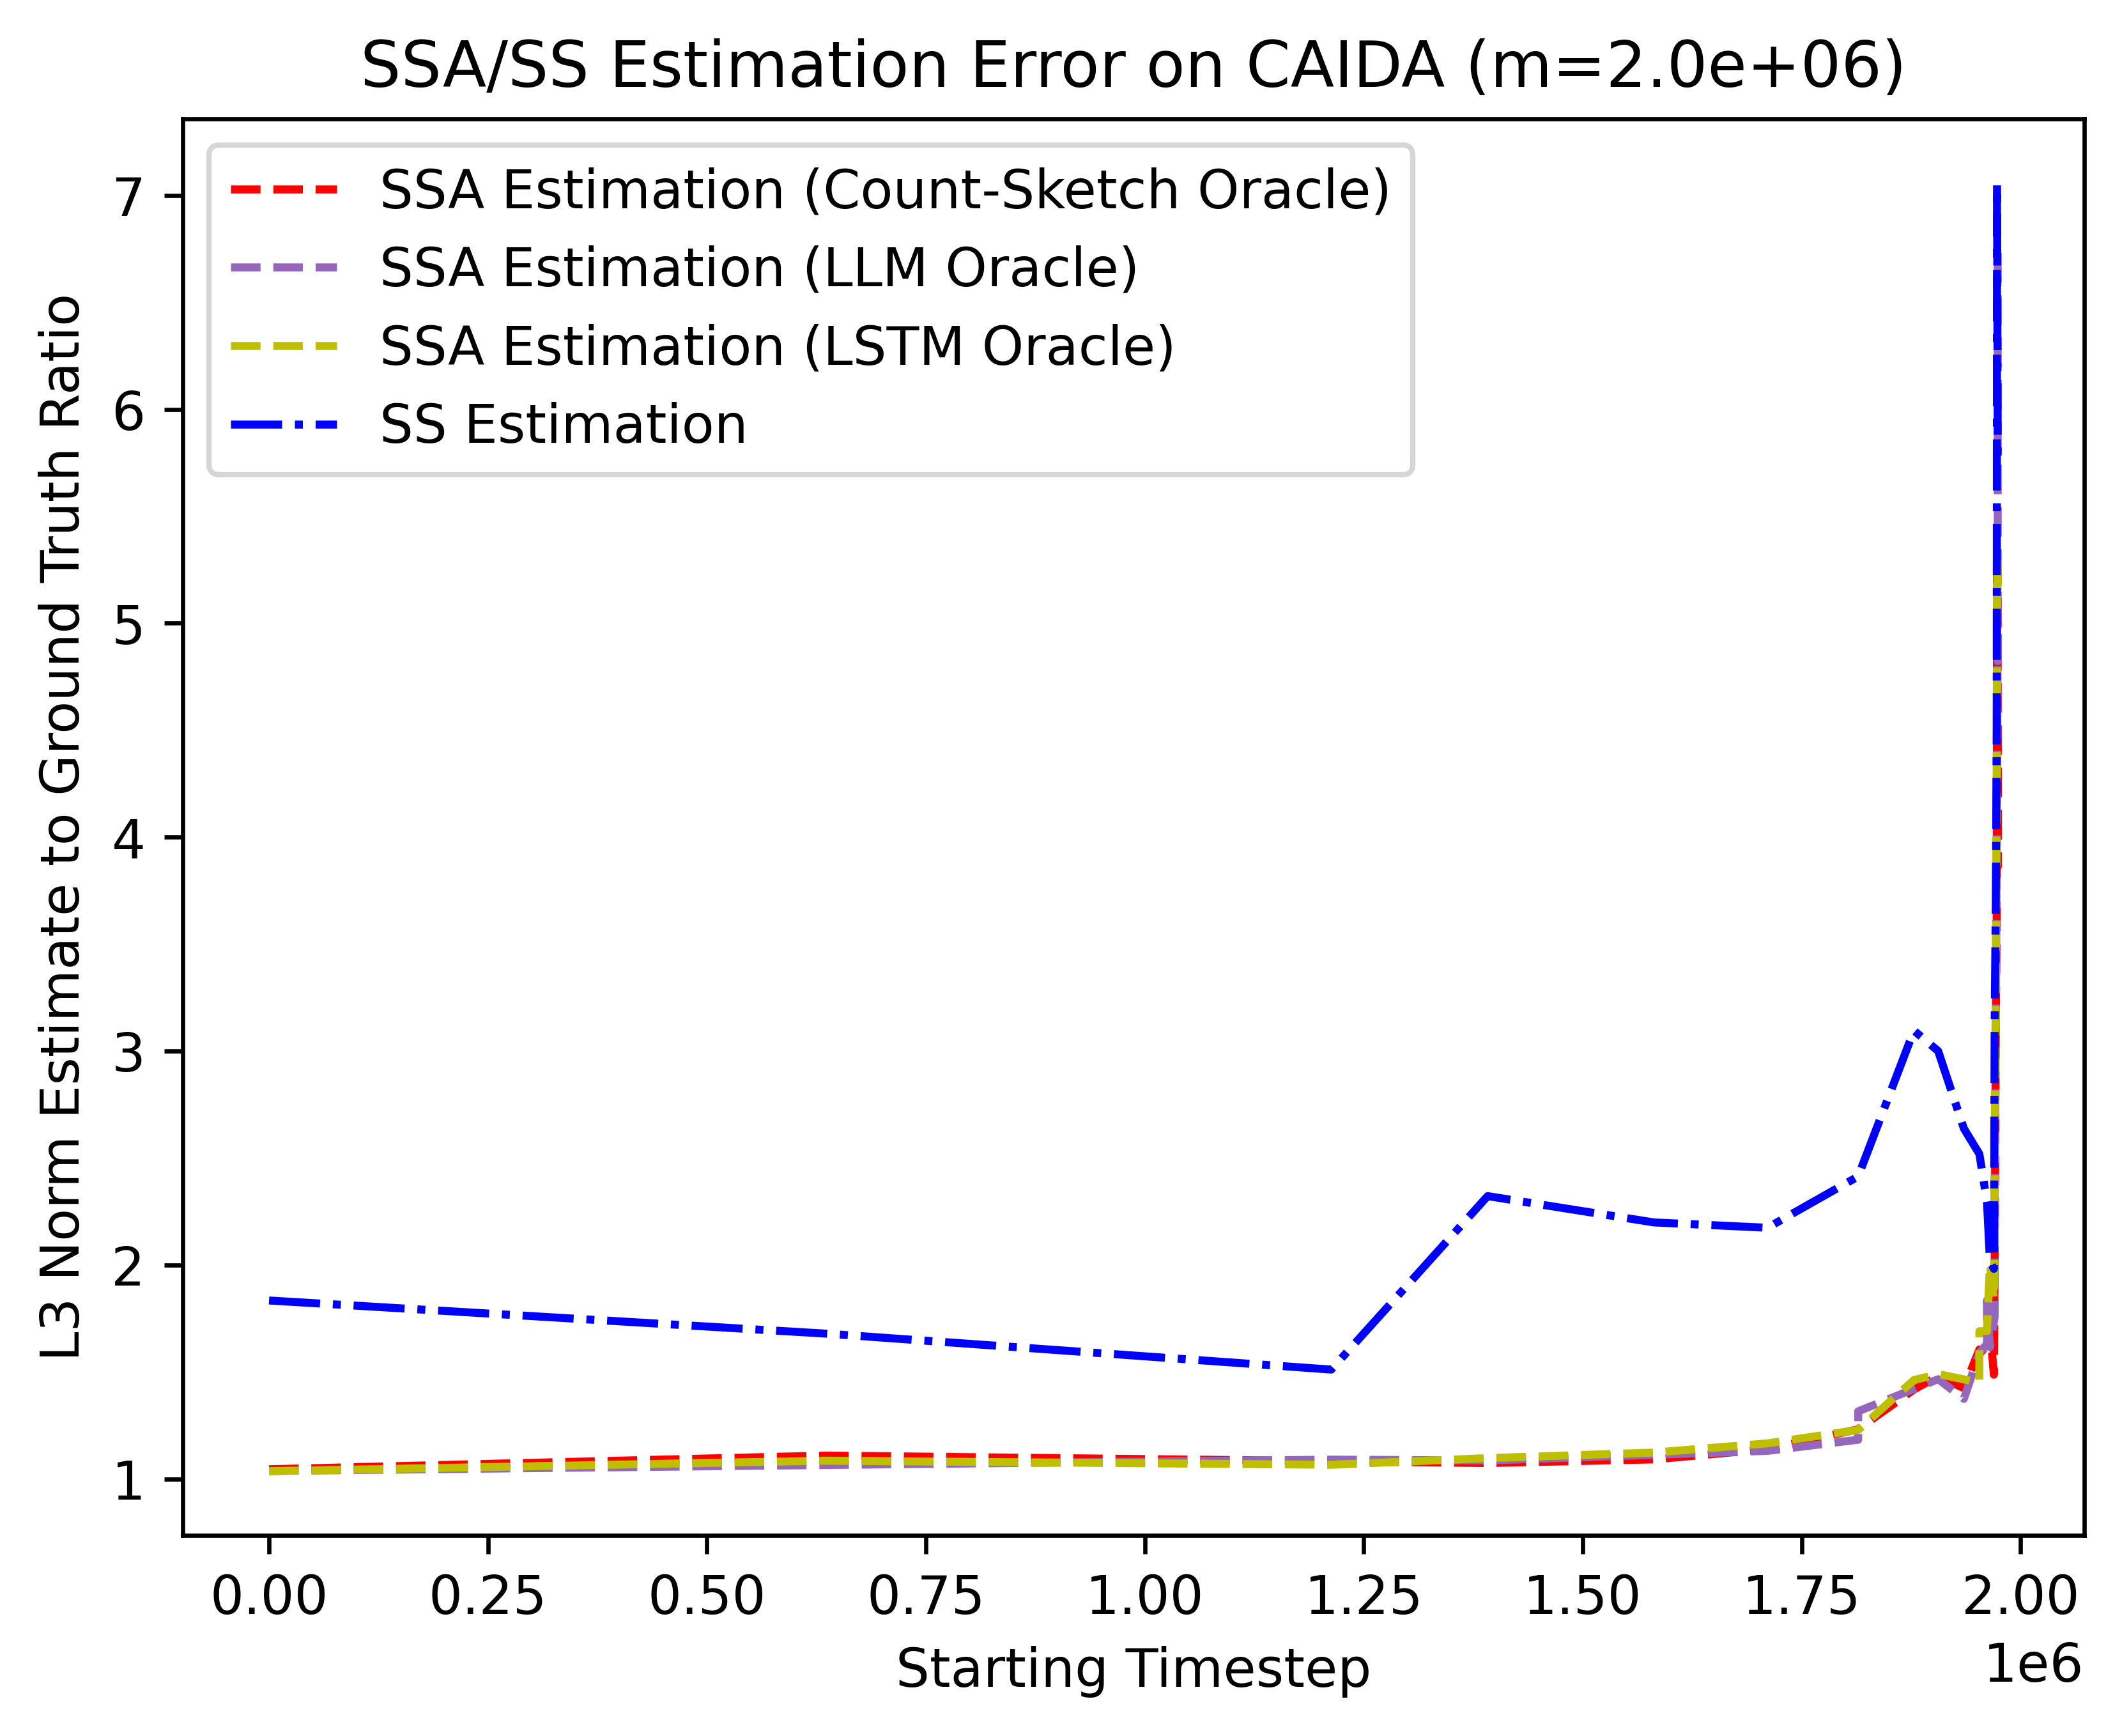

In [10]:
_, ax2 = plt.subplots()
ax2.plot(cs_vals["Timestep"], cs_vals["SSA Error"], 'r--', label="SSA Estimation (Count-Sketch Oracle)")
ax2.plot(gem_vals["Timestep"], gem_vals["SSA Error"], '--', label="SSA Estimation (LLM Oracle)", 
         color="tab:purple")
ax2.plot(lstm_vals["Timestep"], lstm_vals["SSA Error"], 'y--', label="SSA Estimation (LSTM Oracle)",)
ax2.plot(cs_vals["Timestep"], cs_vals["SS Error"], 'b-.',label="SS Estimation")
ax2.set_xlabel("Starting Timestep")
ax2.set_ylabel("L3 Norm Estimate to Ground Truth Ratio")
ax2.set_title(f"SSA/SS Estimation Error on CAIDA (m={m:.1e})")
ax2.legend()
plt.show()

## Selection Probability Experiment

In [4]:
import pandas as pd
m = int(2e5)
W = int(m/2) 
rm_space = lambda x: x.strip()
cs_buckets = pd.read_csv("Data/ss-ssa-count-sketch-buckets.txt").rename(rm_space, axis="columns")
gem_buckets = pd.read_csv("Data/ss-ssa-gemini-buckets-26.txt").rename(rm_space, axis="columns")
lstm_buckets = pd.read_csv("Data/ss-ssa-lstm-buckets.txt").rename(rm_space, axis="columns")

In [5]:
cs_buckets

,Ground Truth,SSA Estimate,SS Estimate,q
0,2498.5,2332.012,1947.617,0.100
1,2498.5,2917.421,1966.489,0.050
2,2498.5,1627.234,1156.132,0.025
3,2498.5,2989.705,2191.144,0.013
4,2498.5,2403.571,1194.756,0.006
5,2498.5,2249.725,1147.911,0.003
6,2498.5,2754.036,539.749,0.002


In [6]:
gem_buckets

,Ground Truth,SSA Estimate,SS Estimate,q
0,2498.5,3140.352,2375.871,0.100
1,2498.5,1767.849,1265.273,0.050
2,2498.5,2199.150,1585.618,0.025
3,2498.5,2527.873,2117.774,0.013
4,2498.5,2651.631,1220.491,0.006
5,2498.5,2050.712,1141.815,0.003
6,2498.5,1442.512,378.645,0.002


In [7]:
lstm_buckets

,Ground Truth,SSA Estimate,SS Estimate,q
0,2498.5,2890.864,2234.941,0.100
1,2498.5,2776.064,1927.413,0.050
2,2498.5,2078.088,1581.844,0.025
3,2498.5,1877.337,1543.289,0.013
4,2498.5,1662.805,914.019,0.006
5,2498.5,2275.457,1163.599,0.003
6,2498.5,2149.537,451.642,0.002


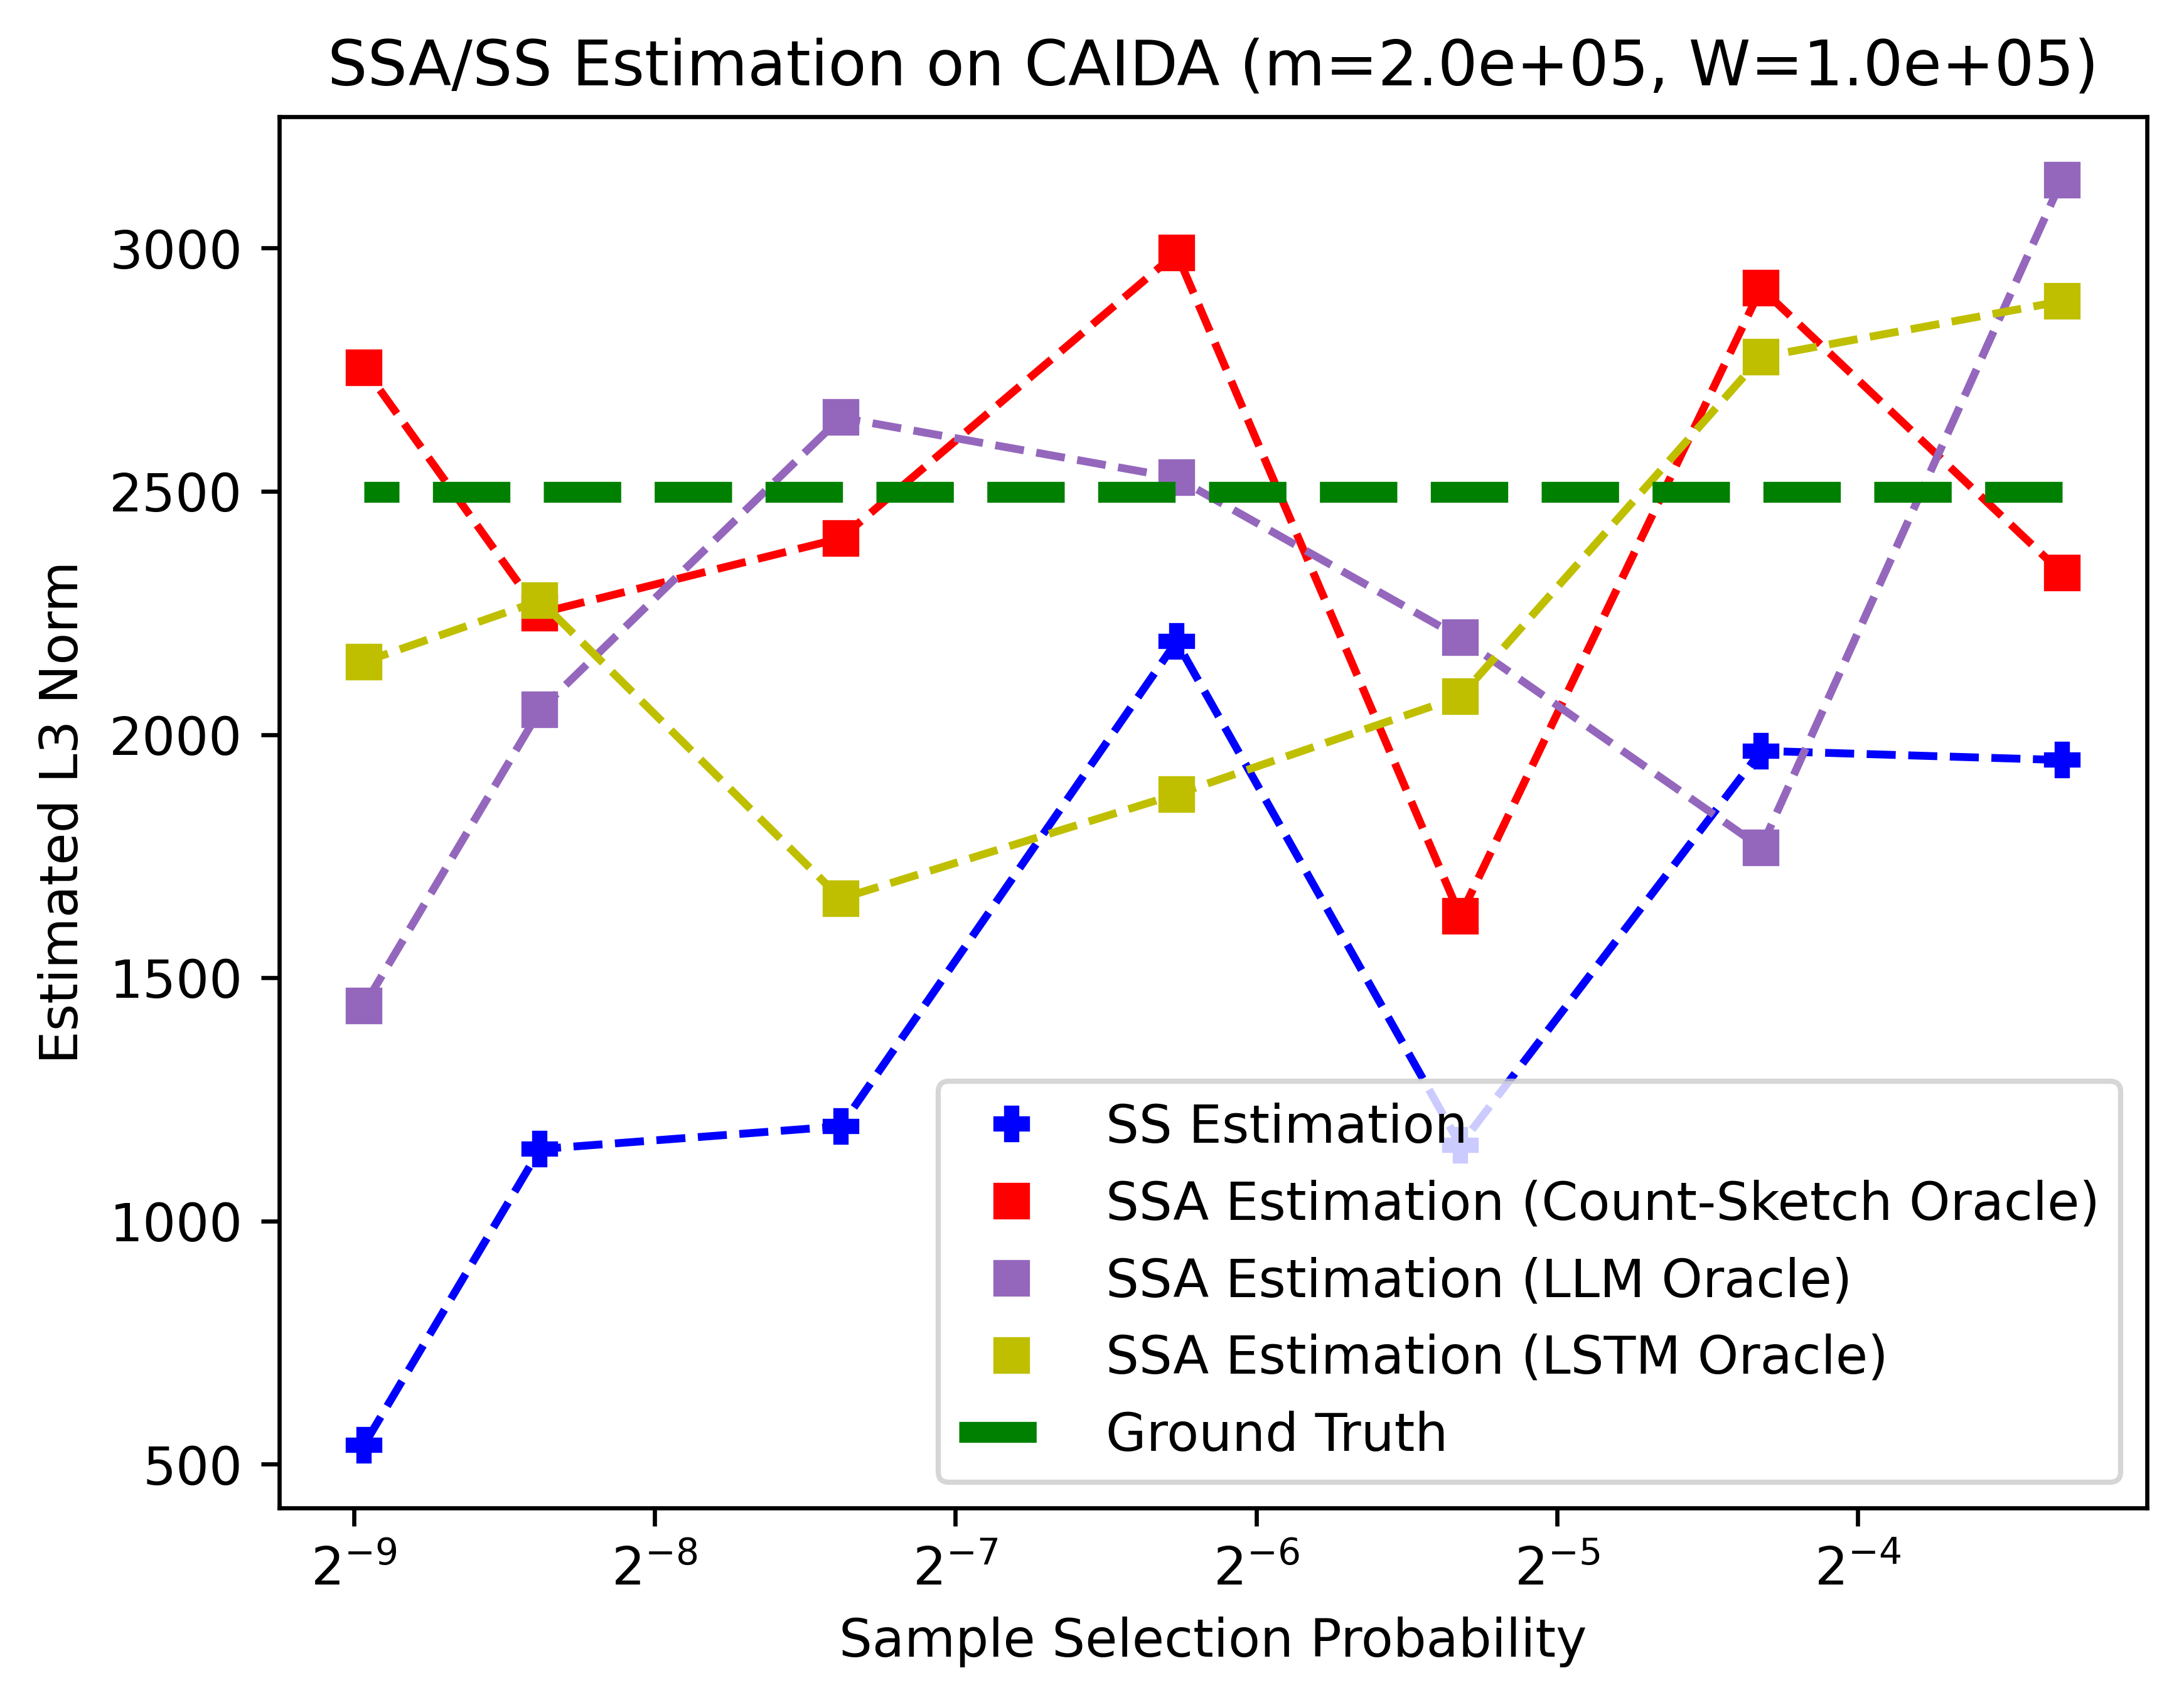

In [9]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["figure.dpi"] = 600


_, ax = plt.subplots()

ax.plot(cs_buckets["q"], cs_buckets["SS Estimate"], 'b--')
ax.plot(cs_buckets["q"], cs_buckets["SS Estimate"], 'bP', label='SS Estimation')

ax.plot(cs_buckets["q"], cs_buckets["SSA Estimate"], 'r--')
ax.plot(cs_buckets["q"], cs_buckets["SSA Estimate"], 'rs', label='SSA Estimation (Count-Sketch Oracle)')



ax.plot(gem_buckets["q"], gem_buckets["SSA Estimate"], '--',color="tab:purple")
ax.plot(gem_buckets["q"], gem_buckets["SSA Estimate"], 's', label="SSA Estimation (LLM Oracle)", color="tab:purple")

ax.plot(lstm_buckets["q"], lstm_buckets["SSA Estimate"], 'y--')
ax.plot(lstm_buckets["q"], lstm_buckets["SSA Estimate"], 'ys', label="SSA Estimation (LSTM Oracle)")

ax.plot(cs_buckets["q"], cs_buckets["Ground Truth"], 'g--', label='Ground Truth', linewidth=4)


ax.set_xscale('log', base=2)
ax.set_title(f"SSA/SS Estimation on CAIDA (m={m:.1e}, W={W:.1e})")
ax.set_ylabel("Estimated L3 Norm")
ax.set_xlabel("Sample Selection Probability")
ax.legend()
plt.show()